# Module 08 — Unsupervised Learning: Patterns Without Answers

*Hide the diagnosis column. Would the data have discovered tumor types on its own?*

This is the same dataset you used in Module 07: in the early 1990s, physician William Wolberg at the University of Wisconsin, working with computer scientists Nick Street and Olvi Mangasarian, digitized microscope images of **fine-needle aspirates** — a thin needle draws a few cells from a breast lump — and measured 30 properties of the cell nuclei for 569 patients. Back then, you trained models *with the pathologists' answers in hand*.

Today we take the answers away. We'll load the data, immediately seal the diagnosis column in an envelope, and spend the whole module working label-free — asking whether the measurements alone reveal natural tumor groups. This is **unsupervised learning**, and it is everyday biology: when you sequence 10,000 single cells (scRNA-seq), nobody has labeled the cell types — clustering finds them. Breast cancer's famous molecular subtypes (luminal A, luminal B, HER2-enriched, basal-like) were *discovered* around the year 2000 by clustering tumor gene-expression profiles, not decided in advance.

At the very end, we open the envelope and see how close the data got to the pathologists. Run each cell in order, and predict what it will show before you run it — every non-obvious line has a `#` comment explaining what it does.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")
palette = sns.color_palette("colorblind")

# One fixed color per cluster, reused in every plot of this module.
CLUSTER_COLORS = [palette[0], palette[1]]   # blue = cluster 0, orange = cluster 1

## 1. Load the data — then hide the answers

Every model so far was **supervised**: it saw measurements *and* the correct answers, like a student studying with the answer key. **Unsupervised learning** gets no answer column at all. Three things change:

- **No accuracy.** There is no "right answer" to be right about.
- **No train/test split.** We aren't predicting future patients (Module 07's worry); we're *describing* this cohort, so every tumor gets used.
- **A different question.** Not "can you predict the label?" but "**do natural groups exist at all?**"

The one loaded below has 33 columns: an `id`, the `diagnosis` (the pathologist's verdict: `"M"` = malignant, `"B"` = benign), 30 measurements, and one junk column. Watch what we do with `diagnosis`.

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (Modules 01-07)

full = load_dataset("scikit-learn/breast-cancer-wisconsin", split="train").to_pandas()

# THE TRICK OF THIS MODULE: seal the answers in an envelope.
# We store the diagnosis in its own variable and promise not to
# look at it until section 9. Everything in between is label-free.
hidden_diagnosis = full["diagnosis"]   # "M" or "B" -- sealed until the reveal!

# Keep only the 30 measurement columns. drop(columns=...) removes columns by name:
#   - "id" is just a patient number, not biology
#   - "diagnosis" is the answer we're hiding
#   - "Unnamed: 32" is an empty junk column (a leftover comma in the original CSV)
measurements = full.drop(columns=["id", "diagnosis", "Unnamed: 32"])

print("tumors:", measurements.shape[0])
print("measurements per tumor:", measurements.shape[1])
measurements.head(3)   # first-look ritual (Module 02): always peek at the rows

tumors: 569
measurements per tumor: 30


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


Each tumor is now just a row of 30 numbers — nucleus radius, texture, perimeter, area, smoothness, concavity, and so on (each as a mean, an extreme value, and a variability measure). From here on, we know *nothing* about which tumors are malignant.

## 2. Scale first — clustering runs on distance

In Module 07 you met `StandardScaler` and the rule "scale your features." For clustering it's not just a good idea — it's the difference between an analysis and nonsense.

Clustering decides which tumors are "similar" by computing the **distance** between their rows of numbers. But look at the raw units: `area_mean` runs in the hundreds while `smoothness_mean` lives around 0.1. Unscaled, the distance between two tumors is essentially *just their difference in area* — the other 29 measurements contribute rounding error. It's like comparing species by weighing them in grams while scoring every other trait from 0 to 1: the whale-vs-mouse weight gap would drown out everything else, and your "phylogeny" would just be a ranking by weight.

A supervised model can learn to down-weight a feature. Distance can't — so *we* must put all 30 measurements on the same footing first.

In [3]:
from sklearn.preprocessing import StandardScaler   # same tool as Module 07

# The problem, in numbers: two columns living on wildly different scales.
print(measurements[["area_mean", "smoothness_mean"]].describe().round(3))

# StandardScaler rewrites each column as a z-score: "how many standard
# deviations above (+) or below (-) that column's average is this tumor?"
scaler = StandardScaler()
scaled_array = scaler.fit_transform(measurements)   # returns a plain NumPy array

# Wrap the array back into a DataFrame so we keep the column names.
scaled = pd.DataFrame(scaled_array, columns=measurements.columns)

print()
print("after scaling -- every column now has mean 0 and spread 1:")
print(scaled[["area_mean", "smoothness_mean"]].describe().round(3))

       area_mean  smoothness_mean
count    569.000          569.000
mean     654.889            0.096
std      351.914            0.014
min      143.500            0.053
25%      420.300            0.086
50%      551.100            0.096
75%      782.700            0.105
max     2501.000            0.163

after scaling -- every column now has mean 0 and spread 1:
       area_mean  smoothness_mean
count    569.000          569.000
mean      -0.000           -0.000
std        1.001            1.001
min       -1.454           -3.112
25%       -0.667           -0.711
50%       -0.295           -0.035
75%        0.364            0.636
max        5.251            4.771


Now a distance of 1 along `area_mean` means exactly the same thing as a distance of 1 along `smoothness_mean`: "one standard deviation apart." Every method in this module — k-means, hierarchical clustering, PCA — will use this `scaled` table.

(No leakage worries this time, by the way: Module 07's sin was letting *test-set* information touch training. With no prediction task there's no test set to leak into.)

## 3. K-means on two measurements you can see

Thirty dimensions are impossible to look at, so let's start where our eyes work: just two measurements, `radius_mean` (average nucleus size) and `texture_mean` (variation in how darkly the nucleus stains). First, the honest label-free view — every tumor in gray.

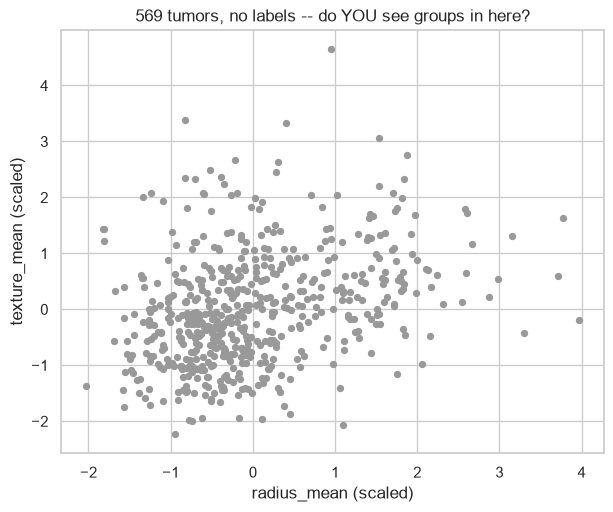

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(scaled["radius_mean"], scaled["texture_mean"], color="0.6", s=18)
ax.set_xlabel("radius_mean (scaled)")
ax.set_ylabel("texture_mean (scaled)")
ax.set_title("569 tumors, no labels -- do YOU see groups in here?")
plt.show()

Squint and you can maybe convince yourself there's a dense lump on the left and a looser cloud stretching to the upper right — but eyeballing isn't a method. **K-means** is the simplest clustering algorithm: you tell it how many groups to look for (that number is called **k**), and it finds k "centers" and assigns every point to its nearest center. We'll ask for 2 — just a starting guess, which section 5 will put to the test.

In [5]:
from sklearn.cluster import KMeans   # scikit-learn's k-means implementation

# Double square brackets pick two columns, giving a 569 x 2 table.
two_features = scaled[["radius_mean", "texture_mean"]]

# n_clusters=2 : look for two groups (our guess for now)
# n_init=10    : run 10 times from different random starts, keep the best run
#                (k-means can get stuck in a bad layout -- restarts protect us)
kmeans_2d = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_2d.fit(two_features)

# .labels_ holds one number per tumor (0 or 1): which cluster it was assigned to.
clusters_2d = kmeans_2d.labels_
print("tumors in cluster 0:", (clusters_2d == 0).sum())   # True counts as 1 (Module 01)
print("tumors in cluster 1:", (clusters_2d == 1).sum())

tumors in cluster 0: 210
tumors in cluster 1: 359


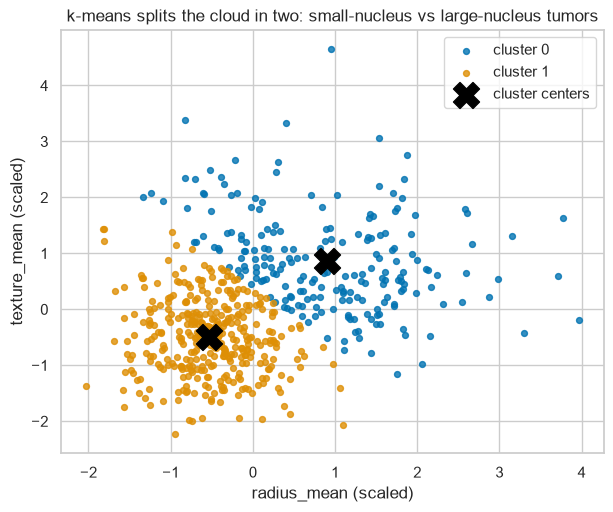

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))

# One scatter call per cluster, so each cluster gets its own color and legend entry.
for c in range(2):
    members = two_features[clusters_2d == c]   # boolean mask (Module 01): rows in cluster c
    ax.scatter(members["radius_mean"], members["texture_mean"],
               color=CLUSTER_COLORS[c], s=18, alpha=0.8, label=f"cluster {c}")

# .cluster_centers_ holds the final center positions: one row per center.
centers = kmeans_2d.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=350,
           color="black", zorder=5, label="cluster centers")   # zorder=5: draw on top

ax.set_xlabel("radius_mean (scaled)")
ax.set_ylabel("texture_mean (scaled)")
ax.set_title("k-means splits the cloud in two: small-nucleus vs large-nucleus tumors")
ax.legend()
plt.show()

K-means drew the boundary right through the thin part of the cloud: a tight family of smaller, more uniform nuclei (left) and a broader family of larger, more variable ones (right). As a biologist you might already have a suspicion about what those two families *are* — hold that thought until section 9.

## 4. How k-means works — run it by hand

`KMeans.fit()` is not magic; it's two moves repeated until nothing changes:

1. **Assign** — every point joins its nearest center.
2. **Move** — every center jumps to the average position of the points that joined it.

Picture two field stations dropped at random into a study site with two penguin colonies. Each penguin reports to its nearest station; each station then relocates to the middle of its penguins; repeat. After a few rounds, one station sits in each colony and nobody switches anymore — **converged**.

Let's run those two moves ourselves on the same two measurements, and draw each round.

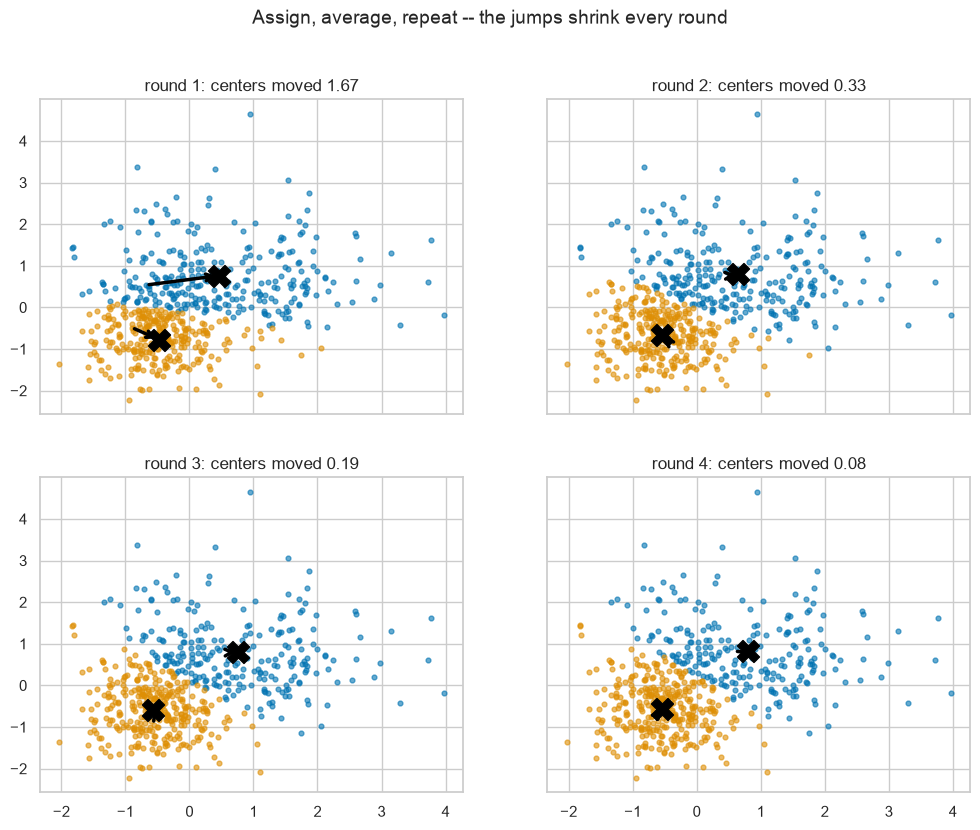

In [7]:
points = two_features.to_numpy()   # .to_numpy(): from table to plain 569 x 2 array

# Start the two centers at two randomly chosen tumors (a common initialization).
rng = np.random.default_rng(42)                              # seeded random generator
start_rows = rng.choice(len(points), size=2, replace=False)  # 2 distinct row numbers
centers = points[start_rows].copy()                          # their coordinates

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

for step in range(4):                # four rounds of assign-then-move
    ax = axes.flat[step]             # axes.flat lists the 4 panels one at a time

    # --- ASSIGN: which center is each tumor closer to? ---
    # For every tumor, its straight-line distance to each center (Module 01 math:
    # subtract, square, sum the two coordinates, square-root).
    dist0 = np.sqrt(((points - centers[0]) ** 2).sum(axis=1))
    dist1 = np.sqrt(((points - centers[1]) ** 2).sum(axis=1))
    # np.where(condition, a, b) returns a where the condition is True, else b:
    # label 1 if the tumor is closer to center 1, otherwise label 0.
    labels = np.where(dist1 < dist0, 1, 0)

    # --- MOVE: each center jumps to the average of its members ---
    new_centers = centers.copy()
    for c in range(2):
        new_centers[c] = points[labels == c].mean(axis=0)   # column-wise average

    # --- DRAW this round: members, the jump arrows, and the new centers ---
    for c in range(2):
        members = points[labels == c]
        ax.scatter(members[:, 0], members[:, 1],
                   color=CLUSTER_COLORS[c], s=12, alpha=0.6)
        # an arrow from where the center was to where it jumped
        ax.annotate("", xy=new_centers[c], xytext=centers[c],
                    arrowprops=dict(arrowstyle="->", lw=2.5, color="black"))
    ax.scatter(new_centers[:, 0], new_centers[:, 1], marker="X", s=250,
               color="black", zorder=5)

    # Total distance the two centers moved this round (small = nearly converged).
    movement = np.sqrt(((new_centers - centers) ** 2).sum(axis=1)).sum()
    ax.set_title(f"round {step + 1}: centers moved {movement:.2f}")   # :.2f = 2 decimals

    centers = new_centers   # the moved centers start the next round

fig.suptitle("Assign, average, repeat -- the jumps shrink every round", fontsize=14)
plt.show()

Round 1 makes a big correction; by round 4 the centers barely twitch. Left to run, they'd soon stop moving entirely — and the result matches what `KMeans` gave us. The real `KMeans` adds only two upgrades: a smarter way to choose the starting positions (called **k-means++**, which spreads the initial centers out), and the `n_init=10` restarts that keep the best of several runs.

## 5. Choosing k — the elbow plot

We guessed k=2. But with the labels sealed, how would we *know* how many groups to ask for? K-means keeps a score that helps: **inertia**, the sum of squared distances from every point to its assigned center — in plain words, *how tightly the clusters hug their members* (smaller = tighter).

Here's the catch: adding more clusters **always** lowers inertia. More field stations always means shorter walks for the penguins, even if the extra stations split real colonies in half. So we don't look for the smallest inertia — we look for the **elbow**: the k where inertia stops dropping dramatically and starts merely drifting. That's the point where extra clusters stop explaining real structure and start slicing up noise.

From here on we cluster on **all 30 scaled measurements**, not just the two we could plot.

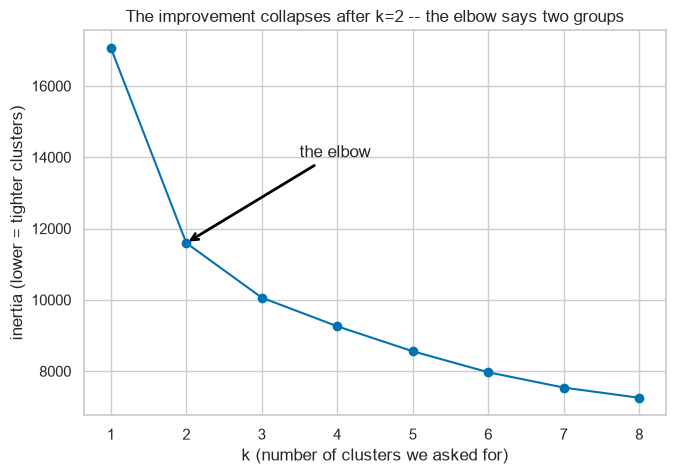

In [8]:
ks = range(1, 9)   # candidate k values: 1 through 8
inertias = []      # we'll collect one inertia score per k

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(scaled)                 # cluster on ALL 30 scaled measurements
    inertias.append(km.inertia_)   # .inertia_ = total squared point-to-center distance

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(list(ks), inertias, marker="o", color=palette[0])
ax.set_xlabel("k (number of clusters we asked for)")
ax.set_ylabel("inertia (lower = tighter clusters)")
ax.set_title("The improvement collapses after k=2 -- the elbow says two groups")
# Circle the elbow so it's impossible to miss.
ax.annotate("the elbow", xy=(2, inertias[1]), xytext=(3.5, 14000),
            fontsize=12, arrowprops=dict(arrowstyle="->", lw=2, color="black"))
plt.show()

Going from 1 cluster to 2 buys a huge drop; from 2 to 3 buys a modest one; after that it's a gentle slide. The bend at k=2 says the data most naturally wants *two* groups.

One honest warning: real elbows are often mushier than this one. The elbow plot is a judgment aid, not a theorem — treat it like reading a gel, not like reading a p-value.

## 6. Hierarchical clustering — a phylogeny of tumors

K-means has two limitations: you must pick k up front, and it returns flat groups with no internal structure. **Hierarchical clustering** fixes both by building a **tree** — and you already know exactly how to read one, because it works like building a phylogeny:

1. Start with every tumor as its own leaf.
2. Find the two most similar groups and **fuse** them.
3. Repeat until everything joins at a single root.

The resulting picture is called a **dendrogram**, and every phylogeny-reading instinct transfers: the pair that fuses lowest are the "sister species" (most similar tumors); a long lone branch is an outlier with no close relatives; and slicing the tree at any height carves the samples into clusters, exactly like choosing to talk about genera instead of species. (We'll use **Ward linkage** — the fusion rule "always merge the two groups that keep clusters tightest," the same greedy spirit as distance-based tree building like UPGMA.)

A tree with 569 leaves would be an unreadable smear, so we'll grow one for a random sample of 60 tumors.

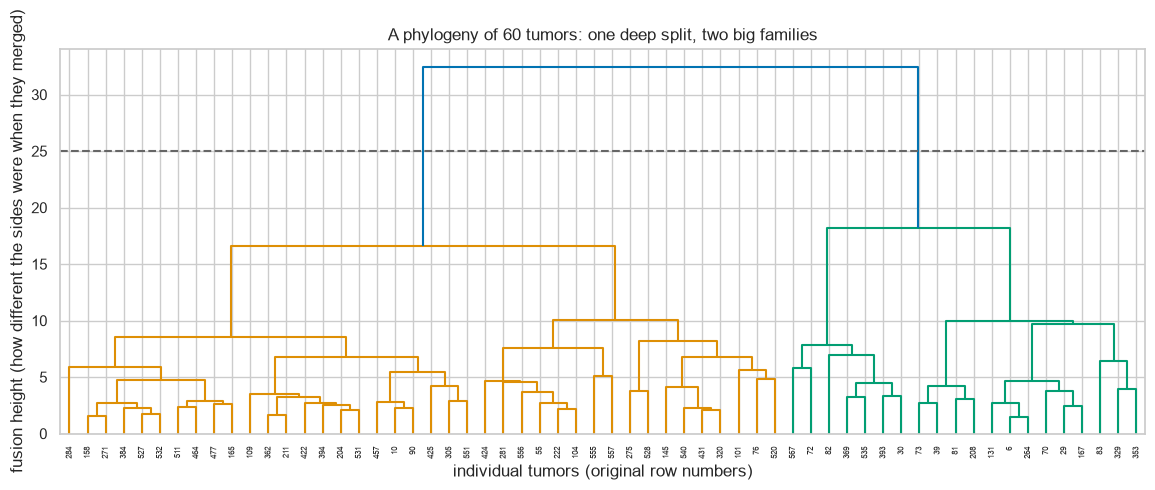

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram   # scipy: scientific toolbox

# .sample(n=60, ...): pick 60 random rows -- enough to see structure, few enough to read.
sample60 = scaled.sample(n=60, random_state=42)

# linkage() replays the whole fusion history: which groups merged, and at what height.
tree = linkage(sample60, method="ward")   # method="ward": keep clusters tightest

fig, ax = plt.subplots(figsize=(14, 5))
# labels=... names each leaf with the tumor's original row number.
# color_threshold=25 paints each family found below height 25 in its own color.
dendrogram(tree, labels=list(sample60.index), color_threshold=25, ax=ax)
ax.axhline(25, linestyle="--", color="0.4")   # axhline: a horizontal line = our "cut"
ax.set_xlabel("individual tumors (original row numbers)")
ax.set_ylabel("fusion height (how different the sides were when they merged)")
ax.set_title("A phylogeny of 60 tumors: one deep split, two big families")
plt.show()

Read it bottom-up like any phylogeny: tumors fusing near height 0 are near-identical siblings; the last, highest join is the deepest divide in the data. Cutting at the dashed line (like drawing a genus boundary) yields **two families — about 40 tumors in one, 20 in the other** — echoing what the elbow plot told us. Two independent methods, same answer: this cohort wants to be two groups.

Keep those two families in mind. The envelope stays sealed... for now.

## 7. The genomics heatmap

Open any tumor-profiling or RNA-seq paper and you'll meet *the* iconic figure: a **clustered heatmap**. Rows are samples, columns are genes (for us: measurements), color shows the value, and dendrograms along both edges reorder rows and columns so that similar things sit together. Subtypes then appear as **blocks of color** — and a single seaborn command, `clustermap`, draws the entire thing: it clusters the rows, clusters the columns, reorders both, and paints the heatmap.

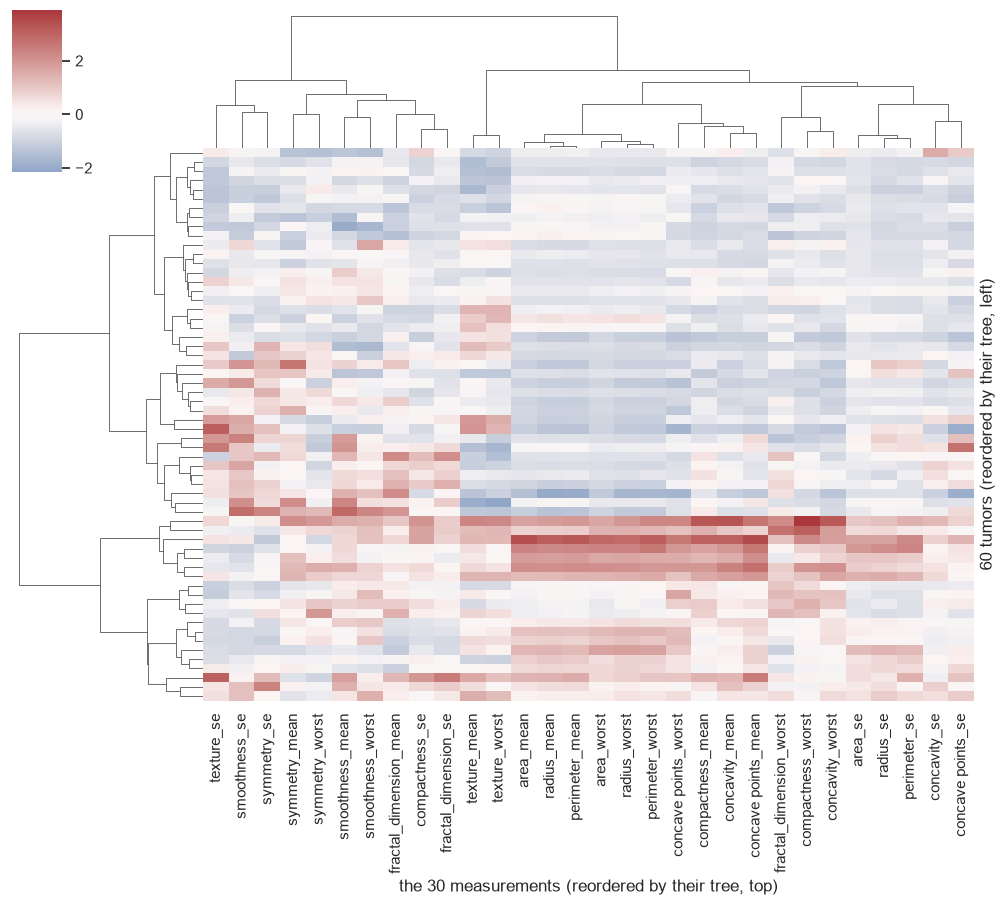

In [10]:
# sns.clustermap creates its own complete figure (heatmap + both dendrograms),
# so there's no plt.subplots() here -- we just call it and show the result.
grid = sns.clustermap(
    sample60,              # our 60 tumors x 30 scaled measurements
    method="ward",         # same fusion rule as our dendrogram above
    cmap="vlag",           # diverging colors: blue = below average, red = above
    center=0,              # value 0 (the average, after scaling) gets the neutral color
    figsize=(10, 9),
    yticklabels=False,     # 60 row numbers on the side would just be clutter
)
grid.ax_heatmap.set_xlabel("the 30 measurements (reordered by their tree, top)")
grid.ax_heatmap.set_ylabel("60 tumors (reordered by their tree, left)")
plt.show()

How to read it, biologist-style:

- The **left dendrogram** is our tumor phylogeny again; the rows are shuffled so relatives are adjacent. Notice the broad band of tumors that are red across many columns — large radius, area, perimeter, concavity all at once — sitting apart from a mostly-blue band.
- The **top dendrogram** clusters the *measurements*: columns that fuse early are redundant cousins (radius, perimeter, and area travel together — geometry guarantees it, since all three grow with nucleus size).
- A rectangular **block of color** = a group of samples that agree on a group of measurements. That's what a "subtype" looks like in print.

This is, at small scale, exactly the figure that defined the breast-cancer expression subtypes in 2000 — same layout, same logic, just with ~500 genes for columns instead of 30 microscope measurements.

## 8. PCA — squashing 30 dimensions into a map

Our tumors live in a 30-dimensional space — one axis per measurement — and we can only ever *plot* two axes at a time. In section 3 we simply picked two and threw away the other 28. **Principal component analysis (PCA)** does something much smarter, and the right mental picture is a **shadow**.

A shadow flattens a 3-D object into 2-D, and how much shape survives depends on the angle of the light: a pencil lit end-on casts a useless dot; lit from the side, its shadow keeps almost everything. PCA finds the *best* angle — the flat view that preserves as much of the cloud's spread as possible. The new axes are called **principal components**: PC1 is the single direction along which the tumors differ most, PC2 is the best remaining direction, and so on. Each component comes with a receipt, the **explained variance ratio**: the fraction of the total variation it kept.

Note that PCA is unsupervised too — it looks only at the measurements' spread, never at any label.

PC1 keeps  44.3 % of all the variation
PC2 keeps  19.0 %
together:   63.2 %


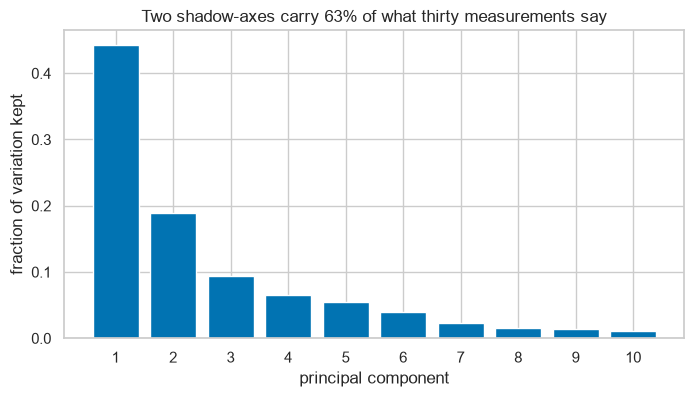

In [11]:
from sklearn.decomposition import PCA

pca = PCA()                          # keep all 30 components so we see the full receipt
coords = pca.fit_transform(scaled)   # each tumor's position on the new PC axes

# .explained_variance_ratio_: the fraction of total variation each PC kept.
ratios = pca.explained_variance_ratio_
print("PC1 keeps ", round(ratios[0] * 100, 1), "% of all the variation")
print("PC2 keeps ", round(ratios[1] * 100, 1), "%")
print("together:  ", round((ratios[0] + ratios[1]) * 100, 1), "%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 11), ratios[:10], color=palette[0])   # just the first 10 of 30 bars
ax.set_xticks(range(1, 11))
ax.set_xlabel("principal component")
ax.set_ylabel("fraction of variation kept")
ax.set_title("Two shadow-axes carry 63% of what thirty measurements say")
plt.show()

Why does one direction carry a whopping 44%? Because the measurements are massively redundant: radius, perimeter, area, and their "worst" versions all track *nucleus size*, so "generally big and irregular vs. generally small and regular" is one giant shared axis of variation. PC1 *is* that axis, discovered automatically.

Now the payoff: cluster the tumors with k-means in the **full 30-dimensional space** (where all the information lives), then use PC1 and PC2 as the map to display the result.

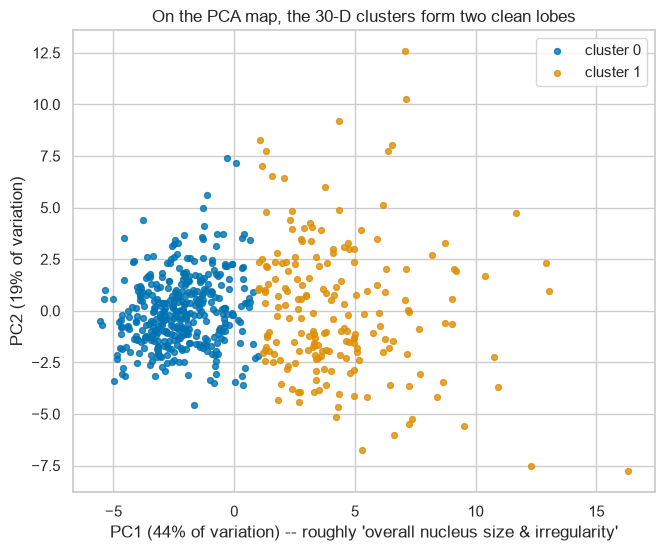

In [12]:
# K-means on ALL 30 scaled measurements -- the map is just for our eyes.
kmeans_all = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_all.fit(scaled)
clusters_all = kmeans_all.labels_    # 0 or 1 for each of the 569 tumors

fig, ax = plt.subplots(figsize=(7.5, 6))
for c in range(2):
    in_c = clusters_all == c         # boolean mask: True for tumors in cluster c
    # coords[in_c, 0] = PC1 values of those tumors; coords[in_c, 1] = their PC2 values.
    ax.scatter(coords[in_c, 0], coords[in_c, 1],
               color=CLUSTER_COLORS[c], s=18, alpha=0.8, label=f"cluster {c}")
ax.set_xlabel("PC1 (44% of variation) -- roughly 'overall nucleus size & irregularity'")
ax.set_ylabel("PC2 (19% of variation)")
ax.set_title("On the PCA map, the 30-D clusters form two clean lobes")
ax.legend()
plt.show()

Two lobes, split cleanly — and remember, k-means never saw this 2-D picture; it worked in the full 30-D space, and the shadow simply *shows* us its verdict. Everything on this map — the coordinates, the colors, all of it — was computed with **zero labels**.

Time to open the envelope.

## 9. The reveal — opening the envelope

Since section 1, `hidden_diagnosis` has been sitting unread: the verdict of the pathologists — humans with microscopes, medical degrees, and the actual patients in front of them. Let's draw the exact same PCA map twice: colored by *our* label-free clusters on the left, and by the *pathologists'* diagnoses on the right.

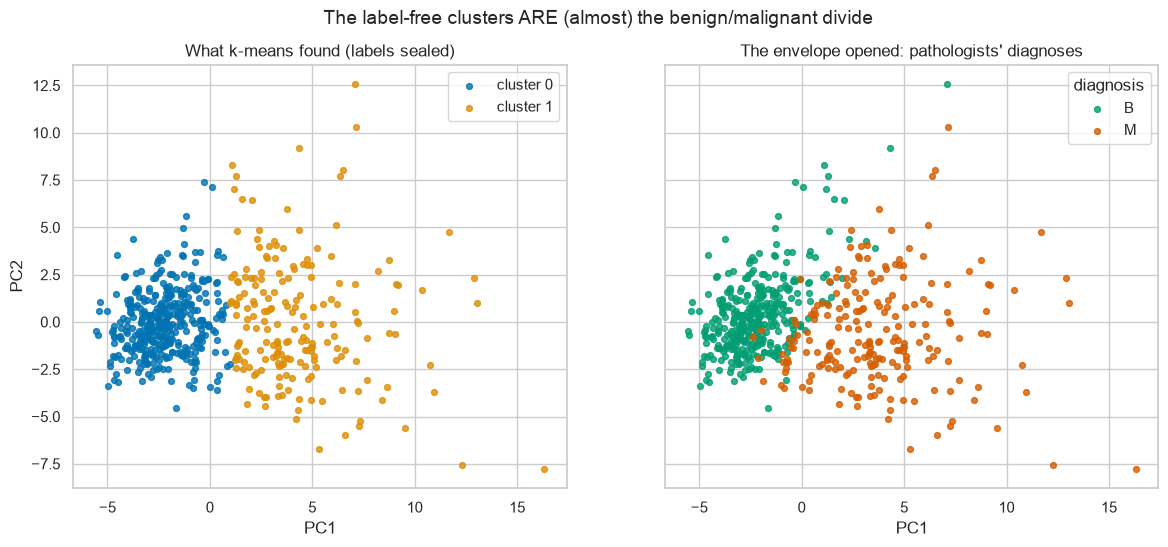

In [13]:
DIAG_COLORS = {"B": palette[2], "M": palette[3]}   # green = benign, red = malignant

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

# LEFT: what unsupervised learning found, no labels used anywhere.
for c in range(2):
    in_c = clusters_all == c
    axes[0].scatter(coords[in_c, 0], coords[in_c, 1],
                    color=CLUSTER_COLORS[c], s=18, alpha=0.8, label=f"cluster {c}")
axes[0].set_title("What k-means found (labels sealed)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# RIGHT: what the pathologists had said all along.
for d in ["B", "M"]:
    is_d = (hidden_diagnosis == d).to_numpy()   # boolean mask as a plain array
    axes[1].scatter(coords[is_d, 0], coords[is_d, 1],
                    color=DIAG_COLORS[d], s=18, alpha=0.8, label=d)
axes[1].set_title("The envelope opened: pathologists' diagnoses")
axes[1].set_xlabel("PC1")
axes[1].legend(title="diagnosis")

fig.suptitle("The label-free clusters ARE (almost) the benign/malignant divide", fontsize=14)
plt.show()

The two pictures are nearly the same map. To score the match precisely, cross-tabulate — `pd.crosstab` from Module 02, counting every combination of (pathologist's verdict) × (our cluster).

In [14]:
# Rows: the pathologists' diagnosis. Columns: our k-means cluster.
table = pd.crosstab(hidden_diagnosis, clusters_all,
                    rownames=["pathologist"], colnames=["k-means cluster"])
print(table)
print()

# Cluster numbers are arbitrary (0 and 1 mean nothing by themselves).
# The table shows cluster 0 is the mostly-benign one, cluster 1 mostly-malignant,
# so agreements = benign tumors in cluster 0 + malignant tumors in cluster 1.
# .loc["B", 0] reads the table cell at row "B", column 0 (Module 02).
agreements = table.loc["B", 0] + table.loc["M", 1]
total = len(hidden_diagnosis)

print("agreements:", agreements, "out of", total, "tumors")
print("that is", round(100 * agreements / total, 1), "% -- found with ZERO labels")

k-means cluster    0    1
pathologist              
B                339   18
M                 36  176

agreements: 515 out of 569 tumors
that is 90.5 % -- found with ZERO labels


**About 91% agreement.** An algorithm that never saw a single diagnosis rediscovered the benign/malignant divide almost as well as the medical gold standard — because malignancy leaves a real, physical signature in nucleus geometry, strong enough that the structure is *in the data itself*.

And the ~54 disagreements? Two rival explanations, both worth taking seriously:

- **The algorithm's fault:** k-means draws a simple boundary, and some tumors just fall on its wrong side.
- **Biology's messiness:** some tumors genuinely straddle the line — small, regular-looking malignancies and large, irregular benign masses exist. In a real study, these borderline cases are exactly where you'd point the microscope next.

This is the same reasoning biologists apply when clustering scRNA-seq cells: the clean clusters get named, and the cells *between* clusters become the interesting question (transitional states? doublets? something new?).

## 10. Honest caveats — clusters are hypotheses, not truth

Module 07 taught the honest-scientist workflow for supervised learning. Unsupervised learning needs its own sterile technique, because nothing here ever says "no":

- **K-means always returns k clusters** — ask for 5 and you'll get 5, whether or not 5 groups exist. The algorithm has no way to answer "actually, there are no groups."
- **K-means assumes round, similar-sized blobs.** Elongated clusters, nested rings, or one huge group next to a tiny one can all fool it.
- **The map depends on your choices.** Different scaling, different measurement sets, different k — different clusters. Our clean result partly reflects that these 30 features were *designed* to capture malignancy.
- **A cluster is a hypothesis.** The expression subtypes of breast cancer earned their names only after they predicted survival and treatment response in independent cohorts. Like a candidate gene, a cluster needs a follow-up experiment before you believe it.

The first point deserves a demonstration. Watch k-means "discover" three clusters in data with **no structure whatsoever**.

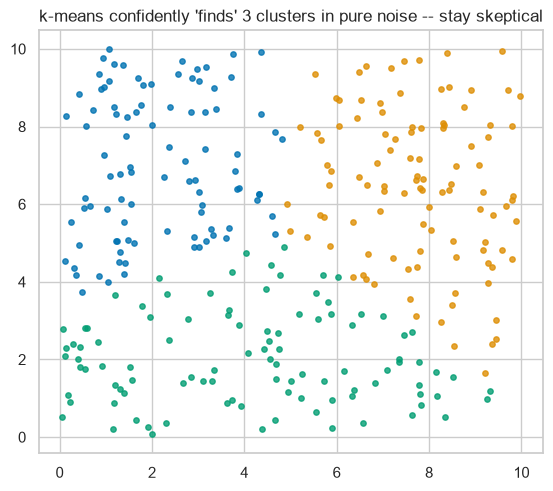

In [15]:
# 300 points scattered uniformly at random -- pure noise, zero real groups.
rng = np.random.default_rng(42)
noise = rng.uniform(low=0, high=10, size=(300, 2))   # uniform = evenly random in a square

kmeans_noise = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_noise.fit(noise)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for c in range(3):
    members = noise[kmeans_noise.labels_ == c]
    ax.scatter(members[:, 0], members[:, 1], color=palette[c], s=15, alpha=0.8)
ax.set_title("k-means confidently 'finds' 3 clusters in pure noise -- stay skeptical")
plt.show()

Three tidy, colorful, utterly meaningless clusters. Nothing in the output warns you. The skepticism has to come from *you* — from elbow plots, from multiple methods agreeing (our k-means, dendrogram, and heatmap all told the same two-group story), and ultimately from independent biological validation.

## Where you stand

You can now find structure in data nobody has labeled — the workhorse skill behind cell-type discovery, tumor subtyping, and half the figures in any genomics paper:

- **k-means** (assign, average, repeat) and the **elbow plot** for choosing k
- **hierarchical clustering**, read exactly like the phylogenies you already know
- the **clustered heatmap**, genomics' favorite figure, in one seaborn call
- **PCA**, the shadow-caster that turns 30 dimensions into an honest 2-D map
- and the discipline to remember that clusters are hypotheses, not verdicts

Head to [exercises.md](exercises.md) to push on these tools. Next module, we leave scikit-learn's ready-made algorithms behind and build a neural network from scratch — with nothing but NumPy.